# **Participants**

- Lyse Priscille NGASSEU NDIFO
- Serigne BASSIROU NDIAYE

# **Présentation générale**

Ce tutoriel a pour objectif d’explorer et de comparer différentes méthodes de reconstruction de réseaux causaux appliquées à des altérations génomiques observées dans des tumeurs du sein. À partir du jeu de données COSMIC, qui regroupe des informations sur la mutation, l’expression génique et la ploidie de 807 échantillons tumoraux, nous cherchons à identifier les relations statistiques et potentielles influences causales entre ces variables biologiques.

Nous mettons en œuvre trois approches complémentaires de reconstruction de réseaux **Hill-Climbing** (méthode score-based), **PC Algorithm** (méthode constraint-based) et **MIIC** (méthode informationnelle robuste). L’objectif est d’évaluer comment ces méthodes structurent les interactions entre gènes mutés, gènes sous- ou sur-exprimés et ploidie, et d’identifier les nœuds centraux (hubs) ainsi que les dépendances les plus significatives.

Ce travail permet d’illustrer les enjeux de la modélisation causale en biologie, notamment dans le contexte du cancer, où les altérations génomiques interagissent de manière complexe. Il offre également une comparaison méthodologique entre trois familles d’algorithmes largement utilisées pour l’inférence de réseaux à partir de données observationnelles.


# **Partie 1 :  Reconstruction du réseau par l’algorithme hill-climbing**

## **Q1 - Chargement et exploration du dataset cosmicCancer**

In [ ]:
install.packages("miic")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘ppcor’




In [ ]:
library(miic)

In [ ]:
# Chargement des données COSMIC
data("cosmicCancer")


In [ ]:
cat("### Dimensions du dataset\n")
print(dim(cosmicCancer))

cat("\n### Structure des variables\n")
str(cosmicCancer)

cat("\n### Résumé statistique\n")
summary(cosmicCancer)

cat("\n### Valeurs manquantes par variable\n")
print(colSums(is.na(cosmicCancer)))

cat("\n### Aperçu des premières lignes\n")
head(cosmicCancer)


### Dimensions du dataset
[1] 807 176

### Structure des variables
'data.frame':	807 obs. of  176 variables:
 $ bbc3    : Factor w/ 2 levels "n","y": 1 1 1 1 1 1 1 1 1 1 ...
 $ egln1   : Factor w/ 2 levels "n","y": 1 1 1 1 1 1 1 1 1 1 ...
 $ tgfb3   : Factor w/ 2 levels "n","y": 1 1 1 1 1 1 1 1 1 1 ...
 $ esm1    : Factor w/ 1 level "n": 1 1 1 1 1 1 1 1 1 1 ...
 $ igfbp5  : Factor w/ 2 levels "n","y": 1 1 1 1 1 1 1 1 1 1 ...
 $ fgf18   : Factor w/ 2 levels "n","y": 1 1 1 1 1 1 1 1 1 1 ...
 $ scube2  : Factor w/ 2 levels "n","y": 1 1 1 1 1 1 1 1 1 1 ...
 $ wisp1   : Factor w/ 2 levels "n","y": 1 1 1 1 1 1 1 1 1 1 ...
 $ flt1    : Factor w/ 2 levels "n","y": 1 1 1 1 1 1 1 1 1 1 ...
 $ hrasls  : Factor w/ 2 levels "n","y": 1 1 1 1 1 1 1 1 1 1 ...
 $ stk32b  : Factor w/ 2 levels "n","y": 1 1 1 1 1 1 1 1 1 1 ...
 $ rassf7  : Factor w/ 2 levels "n","y": 1 1 1 1 1 1 1 1 1 1 ...
 $ dck     : Factor w/ 2 levels "n","y": 1 1 1 1 1 1 1 1 1 1 ...
 $ melk    : Factor w/ 2 levels "n","y": 1 1 1 1 1 

 bbc3    egln1   tgfb3   esm1    igfbp5  fgf18   scube2  wisp1   flt1   
 n:806   n:804   n:804   n:807   n:805   n:802   n:800   n:801   n:799  
 y:  1   y:  3   y:  3           y:  2   y:  5   y:  7   y:  6   y:  8  
                                                                        
 hrasls  stk32b  rassf7  dck     melk    ext1    gnaz    ebf4    mtdh   
 n:806   n:802   n:806   n:805   n:802   n:800   n:801   n:807   n:806  
 y:  1   y:  5   y:  1   y:  2   y:  5   y:  7   y:  6           y:  1  
                                                                        
 pitrm1  qscn6l1 ccne2   ect2    cenpa   lin9    kntc2   mcm6    nusap1 
 n:798   n:807   n:802   n:801   n:807   n:802   n:807   n:801   n:803  
 y:  9           y:  5   y:  6           y:  5           y:  6   y:  4  
                                                                        
 orc6l   tspyl5  rundc1  prc1    rfc4    recql5  cdca7   dtl     col4a2 
 n:807   n:805   n:803   n:803   n:802   n:798   n:


### Valeurs manquantes par variable
    bbc3    egln1    tgfb3     esm1   igfbp5    fgf18   scube2    wisp1 
       0        0        0        0        0        0        0        0 
    flt1   hrasls   stk32b   rassf7      dck     melk     ext1     gnaz 
       0        0        0        0        0        0        0        0 
    ebf4     mtdh   pitrm1  qscn6l1    ccne2     ect2    cenpa     lin9 
       0        0        0        0        0        0        0        0 
   kntc2     mcm6   nusap1    orc6l   tspyl5   rundc1     prc1     rfc4 
       0        0        0        0        0        0        0        0 
  recql5    cdca7      dtl   col4a2   gpr180     mmp9   gpr126  rtn4rl1 
       0        0        0        0        0        0        0        0 
  diaph3 cdc42bpa    palm2  aldh4a1    aytl2    oxct1     peci     gmps 
       0        0        0        0        0        0        0        0 
   gstm3   slc2a3    foxm1    erbb2     esr1     tp53      rb1      myc 
       0      

,bbc3,egln1,tgfb3,esm1,igfbp5,fgf18,scube2,wisp1,flt1,hrasls,⋯,PPP2R2A,CCNE1,PTEN,MDM2,USP7,UBE3A,PLK1,BAX,MET,Ploidy
,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,⋯,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
1,n,n,n,n,n,n,n,n,n,n,⋯,normal,normal,normal,normal,normal,normal,normal,normal,normal,1
2,n,n,n,n,n,n,n,n,n,n,⋯,normal,normal,normal,normal,normal,normal,normal,normal,normal,2
3,n,n,n,n,n,n,n,n,n,n,⋯,normal,normal,normal,normal,normal,normal,normal,normal,normal,2
4,n,n,n,n,n,n,n,n,n,n,⋯,normal,normal,normal,normal,normal,normal,normal,normal,normal,1
5,n,n,n,n,n,n,n,n,n,n,⋯,normal,normal,normal,normal,normal,normal,normal,normal,normal,1
6,n,n,n,n,n,n,n,n,n,n,⋯,under,normal,normal,normal,over,normal,normal,normal,normal,2


L’exploration du dataset **cosmicCancer** montre qu’il contient **807 échantillons** et **176 variables** décrivant des mutations, des niveaux d’expression génique et la ploidie. La plupart des variables sont des **facteurs à 2 ou 3 niveaux**, mais plusieurs gènes présentent **un seul niveau (variables constantes)**, ce qui impose leur suppression avant la reconstruction du réseau. Seule la variable Ploidy contient des valeurs manquantes (8 NA). Ces observations guideront le pré‑traitement nécessaire avant d’appliquer l’algorithme hill-climbing.

## **Q2 - Appel de l’algorithme Hill-Climbing et identification des problèmes**

Ici il est question de lancer hc() du package bnlearn sur les données brutes et observer les problèmes liés aux données observationnelles.

In [ ]:
install.packages('bnlearn')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(bnlearn)

In [ ]:
# Tentative de reconstruction du réseau
hc_raw <- hc(cosmicCancer)


ERROR: Error in check.data(x, allow.missing = TRUE): variable esm1 in the data must have at least two levels.


Lorsque l’on appelle directement l’algorithme hill-climbing sur les données brutes :

```r
hc_raw <- hc(cosmicCancer)
```

on obtient l’erreur suivante :

```
Error in check.data(x, allow.missing = TRUE):
variable esm1 in the data must have at least two levels.
```

Cette erreur signifie que **certaines variables du dataset ne possèdent qu’un seul niveau**. Ces variables sont **constantes** dans tout le dataset.

**Un réseau bayésien ne peut pas inclure une variable qui ne varie pas**, car :  
- elle n’apporte aucune information,  
- elle empêche le calcul des probabilités conditionnelles,  
- elle fait échouer les scores utilisés par hill-climbing (BDeu, BIC…).

C’est exactement ce que bnlearn détecte et refuse.

En plus des variables constantes, d’autres problèmes apparaissent :

- **Typage incorrect de la ploidie**  : `Ploidy` est encodée comme un entier (1, 2, NA) alors qu’elle doit être un **facteur**.

- **Présence de valeurs manquantes** : `Ploidy` contient 8 NA,  bnlearn ne peut pas apprendre un réseau avec des NA.

- **Variables très déséquilibrées** : Certaines mutations n’apparaissent qu’une seule fois (ex : `bbc3`, `rassf7`).  Ce n’est pas bloquant, mais cela rend l’apprentissage instable.



### **Comment résoudre ces problèmes ?**

- **Solution 1** : Supprimer les variables constantes

- **Solution 2** : Convertir la ploidie en facteur

- **Solution 3** : Supprimer les lignes contenant des NA

- **Solution 4** : Et ensuite relancer hill-climbing


##

## **Q3 - Nettoyage des données et relance de hill-climbing**

### **Q3.1 - Suppression des variables constantes**

D’après notre str(), on a plusieurs variables qui ont 1 seul niveau. On les retire automatiquement :

In [ ]:
# Identifions les variables constantes
constant_vars <- sapply(cosmicCancer, function(x) length(unique(x)) == 1)
cat("### Liste des variables constantes\n")
print(constant_vars)


### Liste des variables constantes
    bbc3    egln1    tgfb3     esm1   igfbp5    fgf18   scube2    wisp1 
   FALSE    FALSE    FALSE     TRUE    FALSE    FALSE    FALSE    FALSE 
    flt1   hrasls   stk32b   rassf7      dck     melk     ext1     gnaz 
   FALSE    FALSE    FALSE    FALSE    FALSE    FALSE    FALSE    FALSE 
    ebf4     mtdh   pitrm1  qscn6l1    ccne2     ect2    cenpa     lin9 
    TRUE    FALSE    FALSE     TRUE    FALSE    FALSE     TRUE    FALSE 
   kntc2     mcm6   nusap1    orc6l   tspyl5   rundc1     prc1     rfc4 
    TRUE    FALSE    FALSE     TRUE    FALSE    FALSE    FALSE    FALSE 
  recql5    cdca7      dtl   col4a2   gpr180     mmp9   gpr126  rtn4rl1 
   FALSE    FALSE    FALSE    FALSE    FALSE    FALSE    FALSE    FALSE 
  diaph3 cdc42bpa    palm2  aldh4a1    aytl2    oxct1     peci     gmps 
   FALSE    FALSE    FALSE    FALSE     TRUE    FALSE     TRUE    FALSE 
   gstm3   slc2a3    foxm1    erbb2     esr1     tp53      rb1      myc 
   FALSE    FALS

In [ ]:
# Supprimons ces variables
cosmic_no_const <- cosmicCancer[, !constant_vars]

### **Q3.2 - Conversion de la ploidie en facteur**

Dans notre str(), Ploidy est un integer (1, 2, NA). On le convertit :

In [ ]:
cosmic_no_const$Ploidy <- factor(cosmic_no_const$Ploidy)

### **Q3.3 - Suppression des lignes contenant des NA**

On voit plus haut dans le summary() que seule la **ploidie** (que l'on confirme encore plus bas) contient des NA : **8 lignes**.


In [ ]:
print(colSums(is.na(cosmicCancer)))

    bbc3    egln1    tgfb3     esm1   igfbp5    fgf18   scube2    wisp1 
       0        0        0        0        0        0        0        0 
    flt1   hrasls   stk32b   rassf7      dck     melk     ext1     gnaz 
       0        0        0        0        0        0        0        0 
    ebf4     mtdh   pitrm1  qscn6l1    ccne2     ect2    cenpa     lin9 
       0        0        0        0        0        0        0        0 
   kntc2     mcm6   nusap1    orc6l   tspyl5   rundc1     prc1     rfc4 
       0        0        0        0        0        0        0        0 
  recql5    cdca7      dtl   col4a2   gpr180     mmp9   gpr126  rtn4rl1 
       0        0        0        0        0        0        0        0 
  diaph3 cdc42bpa    palm2  aldh4a1    aytl2    oxct1     peci     gmps 
       0        0        0        0        0        0        0        0 
   gstm3   slc2a3    foxm1    erbb2     esr1     tp53      rb1      myc 
       0        0        0        0        0       

In [ ]:
cosmic_clean <- cosmic_no_const[complete.cases(cosmic_no_const), ]

### **Q3.4 - Calculons la proportion supprimée**

In [ ]:
removed <- nrow(cosmicCancer) - nrow(cosmic_clean)
prop_removed <- removed / nrow(cosmicCancer)


In [ ]:
print(paste("On a", removed, "ligne(s) qui ont été retirées soit une proportion de", prop_removed))

[1] "On a 8 ligne(s) qui ont été retirées soit une proportion de 0.00991325898389095"


### **Q3.5 - Relance de hill-climbing sur les données propres**

In [ ]:
hc_clean <- hc(cosmic_clean)

Warning message in check.data(x, allow.missing = TRUE):
“variable gstm3 in the data has levels that are not observed in the data.”


**Conclusion** :     

Après avoir identifié les problèmes liés aux données brutes, nous avons nettoyé le dataset en supprimant les variables constantes, en convertissant la variable Ploidy en facteur et en retirant les échantillons contenant des valeurs manquantes. L’utilisation de **complete.cases()** a supprimé **8 échantillons** sur **807**, soit environ **0.99 %** du dataset. Les **seules valeurs manquantes** concernaient la variable Ploidy.

Une fois ces corrections appliquées, l’algorithme hill-climbing s'exécute sans erreur, ce qui confirme que les problèmes initiaux provenaient de la structure des données et non de l’algorithme lui-même.

### **Q3.6 - Nettoyage des niveaux fantômes**

Lors de l’appel à hill-climbing, bnlearn génère un warning indiquant que certaines variables possèdent des niveaux non observés dans les données filtrées. Ce message provient du fait que certains facteurs conservent des niveaux théoriques qui ne sont plus présents après suppression des échantillons incomplets. Ces variables ne possèdent alors plus qu’un seul niveau observé, ce qui provoque une erreur lors de l’appel à hill-climbing. Nous avons donc supprimé toutes les variables ayant un seul niveau après nettoyage avant de relancer l’algorithme :  ici **`gstm3`**

In [ ]:
#cosmic_clean <- droplevels(cosmic_clean)

In [ ]:
# 1. Supprimons les colonnes constantes après nettoyage
constant_after <- sapply(cosmic_clean, function(x) length(unique(x)) == 1)
constant_after[constant_after == TRUE]


gstm3 
 TRUE

In [ ]:
# 2. Supprimons ces colonnes
cosmic_clean <- cosmic_clean[, !constant_after]

In [ ]:
hc_clean <- hc(cosmic_clean)

## **Q4 - Conversion et visualisation du réseau**

In [ ]:
install.packages('igraph')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
install.packages('qgraph')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘checkmate’, ‘mnormt’, ‘GPArotation’, ‘pbivnorm’, ‘numDeriv’, ‘quadprog’, ‘gridExtra’, ‘htmlTable’, ‘Formula’, ‘psych’, ‘lavaan’, ‘plyr’, ‘Hmisc’, ‘jpeg’, ‘png’, ‘colorspace’, ‘corpcor’, ‘reshape2’, ‘glasso’, ‘fdrtool’, ‘gtools’, ‘pbapply’, ‘abind’




In [ ]:
library(igraph)
library(qgraph)

In [ ]:
# Conversion du réseau hill-climbing en igraph
g <- as.igraph(hc_clean)



In [ ]:
# Supprimons les nœuds de degré 0
deg <- degree(g)
g <- delete_vertices(g, V(g)[deg == 0])


In [ ]:
print(g)

IGRAPH 30a1f19 DN-- 143 199 -- 
+ attr: name (v/c)
+ edges from 30a1f19 (vertex names):
 [1] PRC1  ->FOXM1    RFC4  ->GMPS     FOXM1 ->CDCA7    FOXM1 ->AURKB   
 [5] CENPA ->CCNE1    FOXM1 ->RFC4     CENPA ->MELK     CCNE1 ->CDKN2A  
 [9] CDCA7 ->MCM6     CENPA ->AURKA    GMPS  ->tp53     FOXM1 ->PLK1    
[13] GPR180->DIAPH3   FOXM1 ->LIN9     NUSAP1->PRC1     GMPS  ->CHEK1   
[17] MCM6  ->RB1      MTDH  ->CCNE2    GMPS  ->ECT2     ECT2  ->BRCA2   
[21] tp53  ->NDRG1    AURKB ->TP53     RFC4  ->HRASLS   RB1   ->GPR180  
[25] CCNE1 ->PITRM1   FOXM1 ->TSPYL5   ECT2  ->CCNE2    FOXM1 ->OXCT1   
[29] CDCA7 ->PALM2    MTDH  ->MAPK14   PRC1  ->AURKA    NUSAP1->ECT2    
+ ... omitted several edges


In [ ]:
# Conversion en matrice d'adjacence
adj <- amat(hc_clean)


In [ ]:
# Supprimons les nœuds de degré 0 dans la matrice d'adjacence
deg_adj <- rowSums(adj) + colSums(adj)
adj_clean <- adj[deg_adj > 0, deg_adj > 0]


In [ ]:
# Attribution des couleurs
#node_names <- V(g)$name
node_names <- colnames(adj_clean)

colors <- ifelse(node_names == "Ploidy", "green",
                 ifelse(grepl("^[a-z]", node_names), "red", "blue"))


In [ ]:
print(node_names)

  [1] "egln1"    "tgfb3"    "igfbp5"   "fgf18"    "scube2"   "wisp1"   
  [7] "flt1"     "hrasls"   "stk32b"   "rassf7"   "dck"      "gnaz"    
 [13] "mtdh"     "pitrm1"   "ccne2"    "ect2"     "lin9"     "mcm6"    
 [19] "nusap1"   "tspyl5"   "rundc1"   "prc1"     "rfc4"     "recql5"  
 [25] "cdca7"    "dtl"      "col4a2"   "gpr180"   "gpr126"   "cdc42bpa"
 [31] "palm2"    "oxct1"    "gmps"     "foxm1"    "erbb2"    "esr1"    
 [37] "tp53"     "rb1"      "myc"      "jun"      "lats2"    "chek1"   
 [43] "aurkb"    "aurka"    "brca1"    "brca2"    "dusp5"    "mst1"    
 [49] "ppp1r13l" "tgfa"     "hif1a"    "ldha"     "ndrg1"    "ppp2r1a" 
 [55] "apobec3b" "pten"     "mdm2"     "usp7"     "plk1"     "bax"     
 [61] "met"      "EGLN1"    "TGFB3"    "ESM1"     "IGFBP5"   "FGF18"   
 [67] "SCUBE2"   "WISP1"    "FLT1"     "HRASLS"   "STK32B"   "RASSF7"  
 [73] "DCK"      "MELK"     "EXT1"     "GNAZ"     "MTDH"     "PITRM1"  
 [79] "CCNE2"    "ECT2"     "CENPA"    "LIN9"     "MCM6"     "NU

In [ ]:
?qgraph.layout.fruchtermanreingold

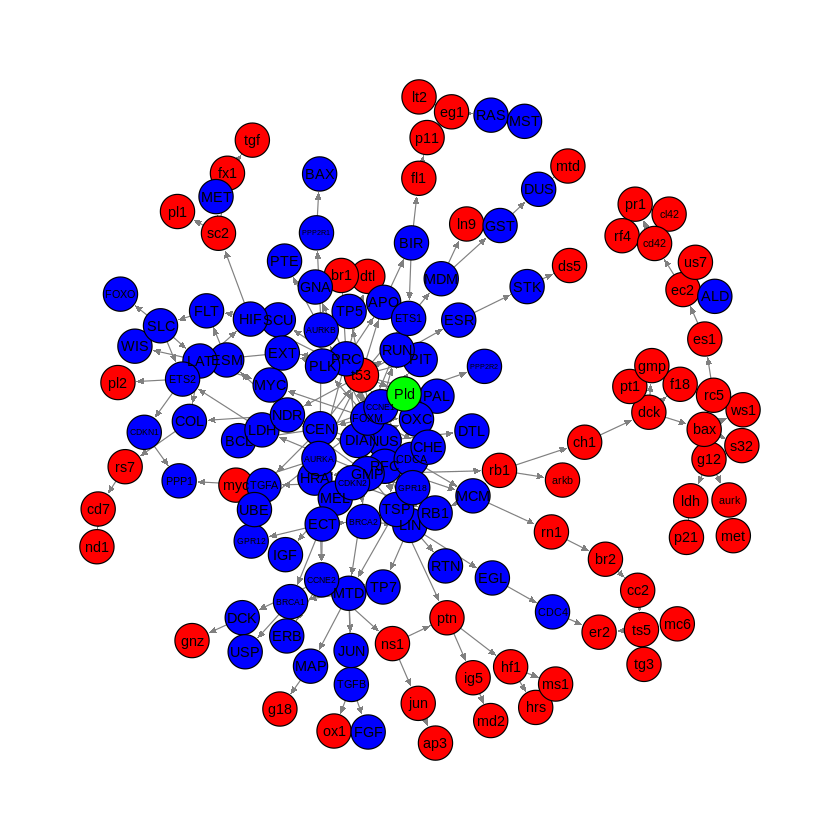

In [ ]:
qgraph(adj_clean,
       layout = "spring",   # = Fruchterman-Reingold
       color = colors,
       vsize = 4,
       directed = TRUE)


### **Analyse du réseau obtenu**

Le graphe obtenu présente une structure dense et orientée, révélant les dépendances apprises entre les variables du jeu de données COSMIC. La disposition circulaire met en évidence plusieurs caractéristiques :

- **Les gènes d’expression (nœuds bleus)** sont fortement interconnectés et concentrés au centre du réseau. Leur densité traduit une forte corrélation entre profils d’expression, cohérente avec des mécanismes biologiques co-régulés.
  
- **Les gènes mutés (nœuds rouges)** sont plus dispersés en périphérie, avec moins de connexions. Cela reflète leur faible fréquence et leur rôle plus localisé dans le réseau de dépendances.

- **La variable Ploidy (nœud vert, ici nommé "PI3")** occupe une position centrale, agissant comme un **hub** reliant plusieurs gènes. Cela suggère un rôle structurel ou régulateur dans le système étudié.

- **La direction des arêtes** indique les dépendances conditionnelles apprises par l’algorithme hill-climbing. Les arcs convergents vers certains nœuds peuvent signaler des variables influencées par plusieurs facteurs.

### **Conclusion**

Ce graphe illustre la capacité de l’algorithme hill-climbing à capturer des dépendances biologiquement plausibles. La centralité de certains gènes d’expression et de la ploidie, ainsi que la périphérie des mutations, sont cohérentes avec les attentes biologiques. Le réseau obtenu pourra servir de base à une analyse plus fine des relations causales ou des modules fonctionnels.

## **Q5.1 - 1. Identifions les gènes mutés (minuscules) liés à des gènes d’expression (majuscules)**

In [ ]:
edges <- as_data_frame(g, what = "edges")

# Identifions les types
is_mut <- function(x) grepl("^[a-z]", x)
is_expr <- function(x) grepl("^[A-Z]", x)

# Relations mutation -> expression ou expression -> mutation
mut_expr_edges <- edges[
  (is_mut(edges$from) & is_expr(edges$to)) |
  (is_expr(edges$from) & is_mut(edges$to)),
]


In [ ]:
mut_expr_edges

,from,to
,<chr>,<chr>
11,GMPS,tp53
21,tp53,NDRG1
34,tp53,EXT1
39,tp53,Ploidy
51,tp53,TP53
52,tp53,MDM2
62,tp53,APOBEC3B
67,tp53,PALM2
68,tp53,TSPYL5


**Relations mutation -> expression (mut_expr_edges)**

On a identifié **39 relations** entre gènes mutés (minuscules) et gènes exprimés (majuscules) :
- Ces arêtes représentent des **dépendances conditionnelles** apprises par hill‑climbing.
- Elles indiquent que certaines mutations sont **statistiquement liées** à l’expression de certains gènes.
- Le gène **tp53** apparaît dans une grande proportion de ces relations (plus de 10 occurrences).

**Interprétation biologique**

- **TP53** est un gène maître régulateur, souvent muté dans les cancers.  
  Le fait qu’il apparaisse comme **source ou cible** dans de nombreuses relations mutation–expression est cohérent :  
  - une mutation de TP53 peut modifier l’expression de nombreux gènes.

- D’autres gènes mutés apparaissent comme points d’entrée vers l’expression :  
  **GMPS, MCM6, PRC1, AURKA, TSPYL5, HIF1A**, etc.

Cela suggère que ces mutations pourraient influencer des programmes transcriptionnels spécifiques.

## **Q5.2 - Identifions les variables liées à la Ploidy**

In [ ]:
ploidy_edges <- edges[edges$from == "Ploidy" | edges$to == "Ploidy", ]


In [ ]:
ploidy_edges

,from,to
,<chr>,<chr>
39,tp53,Ploidy
80,Ploidy,PPP2R2A
104,AURKA,Ploidy


**Variables liées à la ploidie (ploidy_edges)**

On a trouvé **3 relations** :

- **Ploidy** est connectée à des gènes majeurs du cycle cellulaire :
  - **TP53** : régulation du cycle, apoptose, stabilité génomique  
  - **AURKA** : kinase mitotique impliquée dans la ségrégation chromosomique  
  - **PPP2R2A** : sous‑unité de PP2A, régulateur de la division cellulaire

Cela indique que la ploidie est **fortement intégrée dans les mécanismes de division cellulaire**, ce qui est biologiquement cohérent.

## **Q5.3 - Identifions les hubs (nœuds centraux)**

- Un hub = nœud avec haut degré ou forte centralité.

### **Degré :**

In [ ]:
deg <- degree(g)
sort(deg, decreasing = TRUE)[1:10]


tp53 FOXM1  GMPS CENPA  PRC1 AURKA  MTDH CCNE2  ECT2 CCNE1 
   17    15    13    10     9     8     7     7     7     7

**Hubs selon le degré**

Les hubs sont les nœuds avec le plus grand nombre d’arêtes.

- **TP53** est le hub principal : rôle central dans le réseau.
- **FOXM1**, **GMPS**, **CENPA**, **PRC1**, **AURKA** sont des gènes d’expression très connectés.
- Beaucoup de ces gènes sont liés au **cycle cellulaire**, ce qui est cohérent avec les données COSMIC.

Le réseau est **centré sur des régulateurs du cycle cellulaire et de la stabilité génomique**.

### **Betweenness centrality :**

In [ ]:
bet <- betweenness(g, directed = TRUE)
sort(bet, decreasing = TRUE)[1:10]


tp53     MCM6      dck      rb1    chek1      bax    CDCA7    NDRG1 
424.1667 332.0000 300.0000 299.0000 294.0000 256.0000 252.7333 240.0000 
  DIAPH3   gpr126 
232.0000 221.0000

**Hubs selon la betweenness centrality**


La betweenness mesure **l’importance d’un nœud comme point de passage** dans le réseau.

- **TP53** domine encore : c’est le nœud le plus structurant.
- **MCM6**, **RB1**, **CHEK1**, **BAX** sont des gènes clés du cycle cellulaire, de la réparation de l’ADN et de l’apoptose.
- **DCK**, **GPR126**, **DIAPH3** apparaissent comme des nœuds intermédiaires importants.

Ces gènes jouent un rôle de **médiateurs** entre différents modules du réseau.


## **Q5.4 - Top 10 arêtes en betweenness (edge betweenness)**

In [ ]:
edge_bet <- edge_betweenness(g, directed = TRUE)
top_edges <- order(edge_bet, decreasing = TRUE)[1:10]

data.frame(
  from = edges$from[top_edges],
  to   = edges$to[top_edges],
  betweenness = edge_bet[top_edges]
)


from,to,betweenness
<chr>,<chr>,<dbl>
chek1,dck,315.0
rb1,chek1,308.0
CDCA7,MCM6,300.5
dck,bax,272.0
bax,gpr126,238.0
GPR180,DIAPH3,235.0
AURKA,tp53,230.5
MCM6,rb1,212.0
RB1,GPR180,209.0


**Top 10 arêtes en edge betweenness**

Les arêtes à forte betweenness sont les **ponts critiques** du réseau.

- Elles relient des modules fonctionnels distincts.
- Leur suppression fragmenterait le réseau.
- Beaucoup impliquent des gènes du cycle cellulaire ou de la réparation de l’ADN.

Cela confirme que le réseau est structuré autour de **voies de prolifération, d’apoptose et de stabilité génomique**.

## **Q5.5 - Synthèse finale**


Le réseau bayésien appris par hill‑climbing révèle 39 relations entre gènes mutés (minuscules) et gènes exprimés (majuscules). Le gène **tp53** apparaît comme le principal point d’interaction, ce qui est cohérent avec son rôle central dans la tumorigenèse. Plusieurs autres gènes mutés (GMPS, MCM6, PRC1, AURKA, TSPYL5, HIF1A) montrent également des liens significatifs avec l’expression.

La variable **Ploidy** est connectée à **TP53**, **AURKA** et **PPP2R2A**, indiquant une intégration forte dans les mécanismes de division cellulaire et de stabilité génomique.

Les hubs identifiés par le degré sont dominés par **TP53**, **FOXM1**, **GMPS**, **CENPA**, **PRC1** et **AURKA**, tous impliqués dans le cycle cellulaire. La betweenness centrality confirme cette structure : **TP53**, **MCM6**, **RB1**, **CHEK1**, **BAX** et **CDCA7** sont les principaux médiateurs du réseau.

Les arêtes à plus forte betweenness (ex. *chek1 -> dck*, *rb1 -> chek1*, *AURKA -> tp53*) représentent les ponts critiques entre modules fonctionnels.  
Globalement, le réseau est centré sur des gènes clés du cycle cellulaire, de la réparation de l’ADN et de la stabilité génomique.

# **Partie 2&3 : Voir deuxième notebook : PC_MIIC.ipynb**